# 1. Tugas K-Means

Kolom dataset: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


e:\Master\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Master\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Master\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Master\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when the

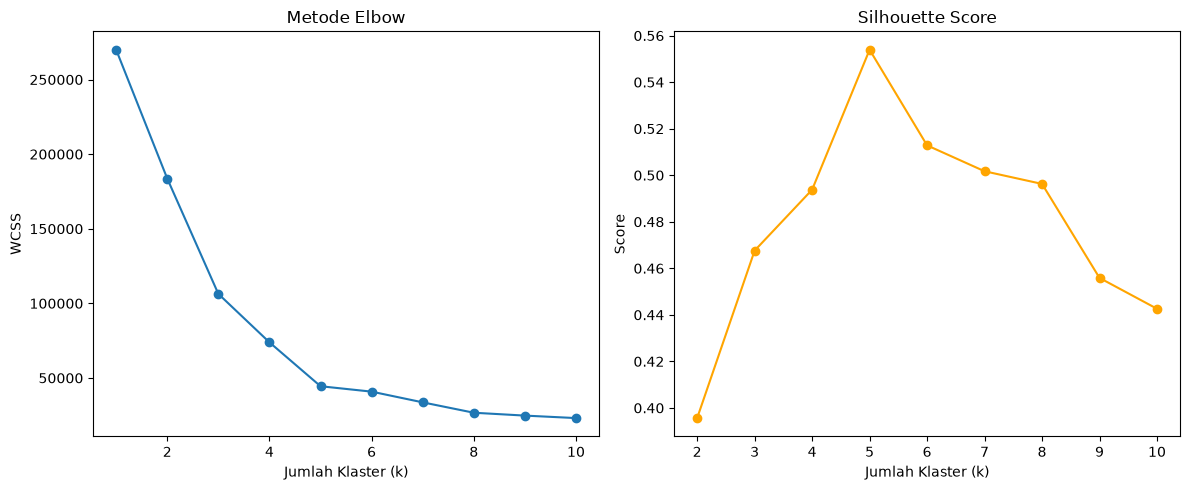

e:\Master\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


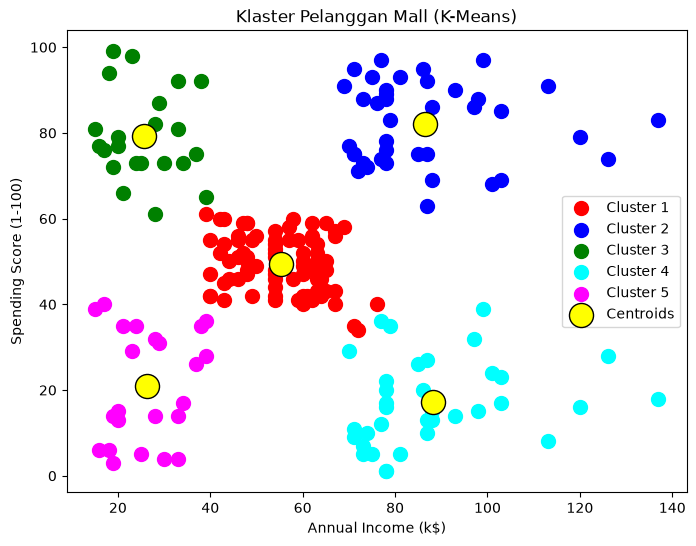


Nilai Silhouette Score terbaik ada pada k = 5


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load data
df = pd.read_csv('docs/Mall_Customers.csv')
print("Kolom dataset:", df.columns.tolist())
print(df.head())

# Features to use: Annual Income and Spending Score are standard for this dataset
# because they form clear customer segments based on purchasing behavior and wealth.
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Determine the best k using Elbow Method and Silhouette Score
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), [KMeans(n_clusters=i, init='k-means++', random_state=42).fit(X).inertia_ for i in range(1, 11)], marker='o')
plt.title('Metode Elbow')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('WCSS')

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Score')

plt.tight_layout()
plt.savefig('elbow_silhouette.png')
plt.show()

# Best K is typically 5 for this dataset
best_k = 5
kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(best_k):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=100, c=colors[i], label=f'Cluster {i+1}')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids', edgecolor='black')
plt.title('Klaster Pelanggan Mall (K-Means)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.savefig('kmeans_clusters.png')
plt.show()

print("\nNilai Silhouette Score terbaik ada pada k =", K_range[np.argmax(silhouette_scores)])

# 2. Tugas DBSCAN

Hasil Evaluasi Dasar (eps=0.2, min_samples=5)
Klaster: 2
Noise: 0
Homogeneity: 1.0000
Completeness: 1.0000
V-Measure: 1.0000
ARI: 1.0000
AMI: 1.0000
Silhouette: 0.3912


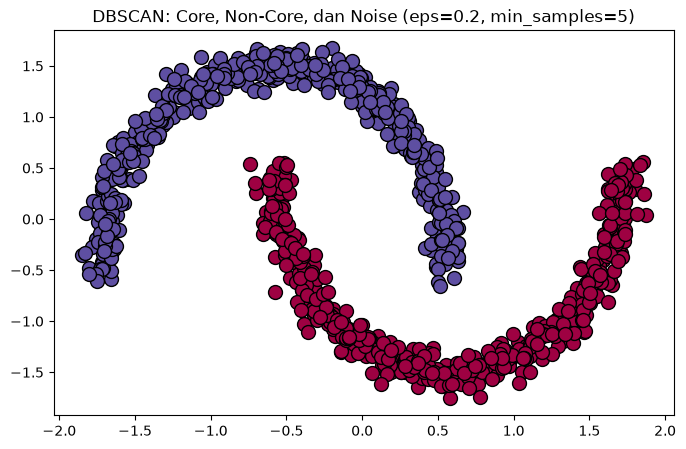


Tabel Eksperimen Variasi Parameter
 eps  min_samples  Klaster  Noise  Homogeneity  Completeness  V-Measure      ARI      AMI  Silhouette
0.05            3       69    186     0.815554      0.152548   0.257021 0.030044 0.243805    0.112929
0.05           10        3    970     0.030669      0.126764   0.049389 0.002283 0.045864   -0.294190
0.05           20        0   1000     0.000000      1.000000   0.000000 0.000000 0.000000         NaN
0.10            3        2     14     0.986207      0.902896   0.942714 0.972179 0.942634    0.251690
0.10           10        7     57     0.943317      0.409546   0.571132 0.523399 0.569801    0.162306
0.10           20        6    850     0.153928      0.155466   0.154693 0.016754 0.150916   -0.360195
0.30            3        2      0     1.000000      1.000000   1.000000 1.000000 1.000000    0.391160
0.30           10        2      0     1.000000      1.000000   1.000000 1.000000 1.000000    0.391160
0.30           20        2      0     1.000000

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

# 1. Siapkan & Normalisasi Data
X, y_asli = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_norm = StandardScaler().fit_transform(X)

# 2. Fungsi Evaluasi yang Lebih Rapi
def cek_metrik(X, y_asli, label):
    jml_klaster = len(set(label)) - (1 if -1 in label else 0)
    jml_noise = list(label).count(-1)
    
    # Silhouette error jika klaster kurang dari 2
    sil = metrics.silhouette_score(X, label) if 1 < jml_klaster < len(X) else None
        
    return {
        'Klaster': jml_klaster,
        'Noise': jml_noise,
        'Homogeneity': metrics.homogeneity_score(y_asli, label),
        'Completeness': metrics.completeness_score(y_asli, label),
        'V-Measure': metrics.v_measure_score(y_asli, label),
        'ARI': metrics.adjusted_rand_score(y_asli, label),
        'AMI': metrics.adjusted_mutual_info_score(y_asli, label),
        'Silhouette': sil
    }

# 3. Jalankan DBSCAN Dasar & Visualisasi
dbscan = DBSCAN(eps=0.2, min_samples=5)
label_dasar = dbscan.fit_predict(X_norm)

plt.figure(figsize=(8, 5))
core_index = dbscan.core_sample_indices_

# plotting menggunakan plt.scatter
for k in set(label_dasar):
    anggota = (label_dasar == k)
    
    if k == -1:
        # Plot Noise (Hitam)
        plt.scatter(X_norm[anggota, 0], X_norm[anggota, 1], c='black', s=20, label='Noise')
    else:
        # Pisahkan Core dan Non-Core
        is_core = np.isin(np.arange(len(X_norm)), core_index)
        
        core = X_norm[anggota & is_core]
        non_core = X_norm[anggota & ~is_core]
        
        warna = plt.cm.tab10(k)
        # Core (Titik Besar)
        plt.scatter(core[:, 0], core[:, 1], c=[warna], s=100, edgecolors='k', label=f'Core {k}')
        # Non-Core (Titik Kecil)
        plt.scatter(non_core[:, 0], non_core[:, 1], c=[warna], s=20, label=f'Non-Core {k}')

plt.title('Visualisasi DBSCAN (eps=0.2, min_samples=5)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)
plt.show()

hasil_eksperimen = []
for eps in [0.05, 0.1, 0.3, 0.5]:
    for min_samples in [3, 10, 20]:
        label_uji = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_norm)
        
        hasil = cek_metrik(X_norm, y_asli, label_uji)
        hasil['eps'] = eps
        hasil['min_samples'] = min_samples
        hasil_eksperimen.append(hasil)

# Menampilkan tabel hasil
df_hasil = pd.DataFrame(hasil_eksperimen)
kolom = ['eps', 'min_samples'] + [kol for kol in df_hasil.columns if kol not in ['eps', 'min_samples']]
print(df_hasil[kolom].to_string(index=False))